## Trap Frequency Investigation

Import libraries

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ExpParams = ExpParameterManager()
exp : MotMasterClient = MotMasterClient()

Rb MotMasterClient initialised.


Initialise and configure devices

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.200 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [3]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## Generate Initial and Final Array Hologram

In [4]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


Initial array

In [5]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.34e-05 | Uniformity: 55.85% | Min/Max ratio: 0.116
Iteration 010 | Mean-Squared Error: 1.76e-07 | Uniformity: 83.32% | Min/Max ratio: 0.481
Iteration 020 | Mean-Squared Error: 6.07e-08 | Uniformity: 83.86% | Min/Max ratio: 0.535
Iteration 030 | Mean-Squared Error: 1.59e-08 | Uniformity: 83.63% | Min/Max ratio: 0.526
Iteration 040 | Mean-Squared Error: 1.08e-08 | Uniformity: 83.65% | Min/Max ratio: 0.522
Iteration 050 | Mean-Squared Error: 2.12e-09 | Uniformity: 83.56% | Min/Max ratio: 0.525
Iteration 060 | Mean-Squared Error: 1.43e-09 | Uniformity: 83.49% | Min/Max ratio: 0.527
Iteration 070 | Mean-Squared Error: 1.38e-09 | Uniformity: 83.49% | Min/Max ratio: 0.528
Iteration 080 | Mean-Squared Error: 1.40e-09 | Uniformity: 83.48% | Min/Max ratio: 0.529
Iteration 090 | Mean-Squared Error: 1.30e-09 | Uniformity: 83.48% | Min/Max ratio: 0.529
Itera

Final array

In [6]:
W2 = np.ones((7,7))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 7x7
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 5.09e-05 | Uniformity: 62.20% | Min/Max ratio: 0.113
Iteration 010 | Mean-Squared Error: 2.00e-07 | Uniformity: 88.13% | Min/Max ratio: 0.606
Iteration 020 | Mean-Squared Error: 4.94e-07 | Uniformity: 86.43% | Min/Max ratio: 0.596
Iteration 030 | Mean-Squared Error: 8.88e-08 | Uniformity: 88.39% | Min/Max ratio: 0.636
Iteration 040 | Mean-Squared Error: 6.51e-09 | Uniformity: 88.53% | Min/Max ratio: 0.643
Iteration 050 | Mean-Squared Error: 1.91e-09 | Uniformity: 88.52% | Min/Max ratio: 0.643
Iteration 060 | Mean-Squared Error: 2.82e-09 | Uniformity: 88.53% | Min/Max ratio: 0.643
Iteration 070 | Mean-Squared Error: 3.41e-09 | Uniformity: 88.54% | Min/Max ratio: 0.643
Iteration 080 | Mean-Squared Error: 5.22e-09 | Uniformity: 88.60% | Min/Max ratio: 0.645
Iteration 090 | Mean-Squared Error: 1.29e-08 | Uniformity: 88.72% | Min/Max ratio: 0.649
Iterati

Load initial array onto the SLM

In [7]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Load and Image Initial Array

In [8]:
ExpParams.set_parameter("tImgCoolVCO", 1.638)
ExpParams.save_parameters()

Parameter 'tImgCoolVCO' set to 1.638.
Parameters saved.


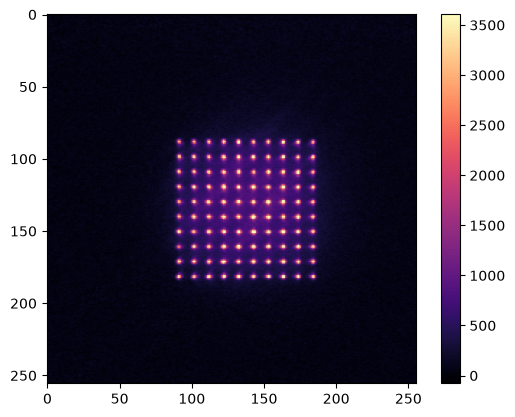

In [9]:
# Experiment and camera setup
n_iterations = 200
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


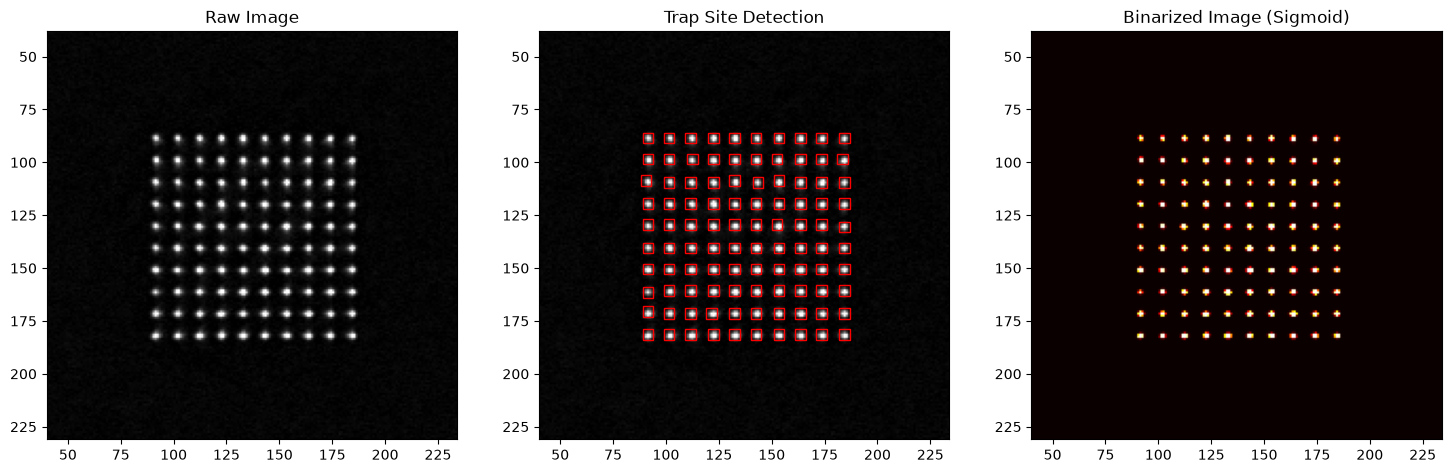

Trap (0, 0) Loading Probability : 58.00 %
Trap (0, 1) Loading Probability : 52.50 %
Trap (0, 2) Loading Probability : 53.00 %
Trap (0, 3) Loading Probability : 61.50 %
Trap (0, 4) Loading Probability : 65.50 %
Trap (0, 5) Loading Probability : 50.00 %
Trap (0, 6) Loading Probability : 56.00 %
Trap (0, 7) Loading Probability : 65.00 %
Trap (0, 8) Loading Probability : 62.00 %
Trap (0, 9) Loading Probability : 57.00 %
Trap (1, 0) Loading Probability : 60.50 %
Trap (1, 1) Loading Probability : 58.00 %
Trap (1, 2) Loading Probability : 52.50 %
Trap (1, 3) Loading Probability : 56.00 %
Trap (1, 4) Loading Probability : 54.00 %
Trap (1, 5) Loading Probability : 57.50 %
Trap (1, 6) Loading Probability : 59.50 %
Trap (1, 7) Loading Probability : 65.50 %
Trap (1, 8) Loading Probability : 55.00 %
Trap (1, 9) Loading Probability : 61.50 %
Trap (2, 0) Loading Probability : 59.00 %
Trap (2, 1) Loading Probability : 57.50 %
Trap (2, 2) Loading Probability : 55.00 %
Trap (2, 3) Loading Probability : 

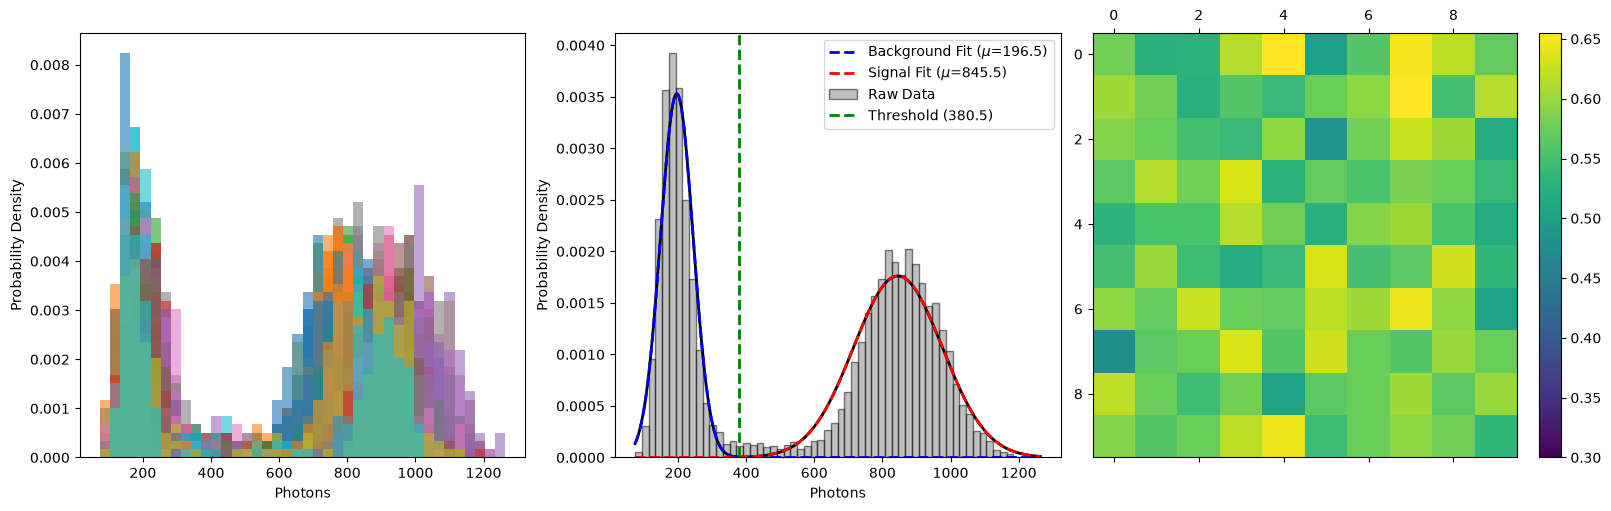

In [10]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60)

Trap (0, 0) Loading Probability : 58.00 %
Trap (0, 1) Loading Probability : 55.50 %
Trap (0, 2) Loading Probability : 54.50 %
Trap (0, 3) Loading Probability : 62.00 %
Trap (0, 4) Loading Probability : 65.50 %
Trap (0, 5) Loading Probability : 51.50 %
Trap (0, 6) Loading Probability : 57.50 %
Trap (0, 7) Loading Probability : 66.00 %
Trap (0, 8) Loading Probability : 64.50 %
Trap (0, 9) Loading Probability : 59.50 %
Trap (1, 0) Loading Probability : 60.50 %
Trap (1, 1) Loading Probability : 58.50 %
Trap (1, 2) Loading Probability : 53.00 %
Trap (1, 3) Loading Probability : 56.50 %
Trap (1, 4) Loading Probability : 55.00 %
Trap (1, 5) Loading Probability : 57.50 %
Trap (1, 6) Loading Probability : 60.00 %
Trap (1, 7) Loading Probability : 66.50 %
Trap (1, 8) Loading Probability : 57.00 %
Trap (1, 9) Loading Probability : 63.00 %
Trap (2, 0) Loading Probability : 60.00 %
Trap (2, 1) Loading Probability : 58.00 %
Trap (2, 2) Loading Probability : 55.00 %
Trap (2, 3) Loading Probability : 

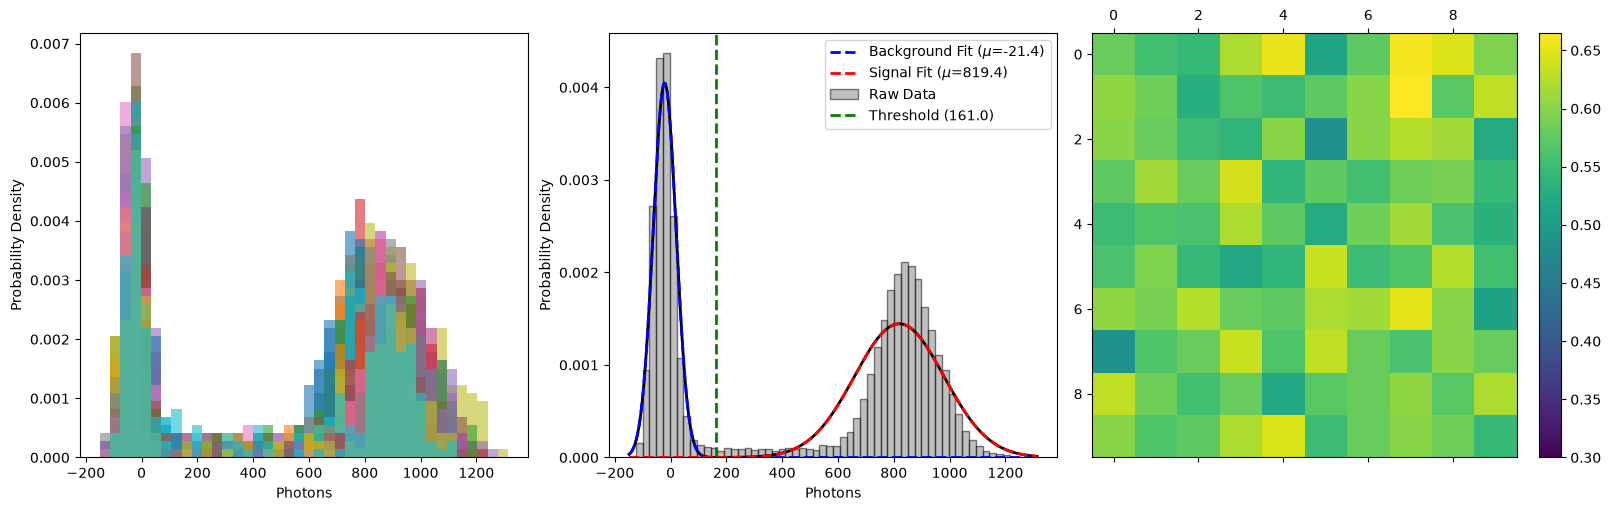

In [11]:
psf_window = 9

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, array_shape_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions_1, array_shape_1, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

### Initial Array Trap Frequency

In [13]:
def frequency_to_voltage(frequency_khz):
    f1, V1 = 10, -10.0  # Point 1: (frequency in kHz, voltage in V)
    f2, V2 = 300, 10.0  # Point 2: (frequency in kHz, voltage in V)
    m = (V2 - V1) / (f2 - f1)
    b = V1 - m * f1
    voltage = m * frequency_khz + b
    return voltage

def voltage_to_frequency(voltage):
    f1, V1 = 10, -10.0  # Point 1: (frequency in kHz, voltage in V)
    f2, V2 = 300, 10.0  # Point 2: (frequency in kHz, voltage in V)
    m = (V2 - V1) / (f2 - f1)
    b = V1 - m * f1
    frequency_khz = (voltage - b) / m
    return frequency_khz

In [15]:
# Experiment and camera setup
N_datapoints = 200
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

modvcflist = np.linspace(frequency_to_voltage(10), frequency_to_voltage(200), N_datapoints)
surv_array = np.zeros_like(modvcflist)

for i, modvcf in enumerate(modvcflist):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
        "BackgroundDrop": 0, "tTweezerModulationVCF": modvcf, "TweezerModulation": 1, "tDelay2": 4000, "tTweezerModulationDuration": 4000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
    surv_array[i] = survival_probability
    print(f"It {i+1}/{N_datapoints}  |  Mod. Frequency = {voltage_to_frequency(modvcf):.2f} kHz  |  Survival probability: {survival_probability*100:.4f} %")

It 1/200  |  Mod. Frequency = 10.00 kHz  |  Survival probability: 93.3573 %
It 2/200  |  Mod. Frequency = 10.95 kHz  |  Survival probability: 92.3668 %
It 3/200  |  Mod. Frequency = 11.91 kHz  |  Survival probability: 91.6065 %
It 4/200  |  Mod. Frequency = 12.86 kHz  |  Survival probability: 95.0091 %
It 5/200  |  Mod. Frequency = 13.82 kHz  |  Survival probability: 91.1064 %
It 6/200  |  Mod. Frequency = 14.77 kHz  |  Survival probability: 92.7418 %
It 7/200  |  Mod. Frequency = 15.73 kHz  |  Survival probability: 92.1989 %
It 8/200  |  Mod. Frequency = 16.68 kHz  |  Survival probability: 91.9390 %
It 9/200  |  Mod. Frequency = 17.64 kHz  |  Survival probability: 92.6068 %
It 10/200  |  Mod. Frequency = 18.59 kHz  |  Survival probability: 92.7483 %
It 11/200  |  Mod. Frequency = 19.55 kHz  |  Survival probability: 93.4039 %
It 12/200  |  Mod. Frequency = 20.50 kHz  |  Survival probability: 90.7000 %
It 13/200  |  Mod. Frequency = 21.46 kHz  |  Survival probability: 90.2702 %
It 14/20

Resonances = 38.56, 45.78, 67.49, 136.85 kHz
Trap Frequencies = 19.28, 22.89, 33.75, 68.42 kHz


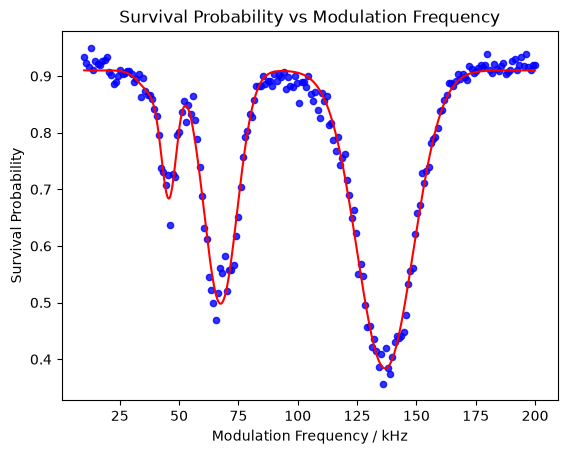

In [18]:
modflist = np.linspace(10, 200, len(modvcflist))

def single_dip_gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + offset

def multi_dip_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, A4, mu4, sigma4, offset):
    return (single_dip_gaussian(x, A1, mu1, sigma1, 0) +
            single_dip_gaussian(x, A2, mu2, sigma2, 0) +
            single_dip_gaussian(x, A3, mu3, sigma3, 0) +
            single_dip_gaussian(x, A4, mu4, sigma4, 0) +  offset)

guess = [-0.1, 25, 1, 
         -0.2, 40, 1, 
         -0.2, 70, 10,
         -0.4, 130, 10,  
          0.9]

popt, pcov = curve_fit(multi_dip_gaussian, modflist, surv_array, p0=guess)
xfit = np.linspace(modflist.min(), modflist.max(), 1000)
yfit = multi_dip_gaussian(xfit, *popt)

plt.scatter(modflist, surv_array, color="blue", alpha=0.8, s=20)
plt.plot(xfit, yfit, color='red')
plt.xlabel("Modulation Frequency / kHz")
plt.ylabel("Survival Probability")
plt.title("Survival Probability vs Modulation Frequency")

print(f"Resonances = {popt[1]:.2f}, {popt[4]:.2f}, {popt[7]:.2f}, {popt[10]:.2f} kHz")
print(f"Trap Frequencies = {popt[1]/2:.2f}, {popt[4]/2:.2f}, {popt[7]/2:.2f}, {popt[10]/2:.2f} kHz")

#### Save Data

In [19]:
import os
import pickle
import time

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\20Aug26"
dataset_title = "initial_10x10_array_trap_frequency_measurement"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save surv_array and modflist to a pickle file
data_to_save = {
    "surv_array": surv_array,
    "modvcflist": modvcflist
}

with open(os.path.join(data_dir, dataset_title, "trap_frequency_data.pkl"), "wb") as f:
    pickle.dump(data_to_save, f)

# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    Trap frequency measurement of the initial 10x10 array, scanning a modulation frequency range from 10 kHz to 200 kHz. Modulation duration used is 40ms. 
    """)

### Final Array Trap Baseline

In [20]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=an.convert_photons_to_counts(threshold_1)*1.1,
    grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
    detector=scorer, num_images=2
)

Occupancy via PSF detector (window 9, threshold 135.4).
Rearrangement node initialised.


In [21]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [22]:
N_iterations = 100  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
                "BackgroundDrop": 0, "tTweezerSetVVA0": 8.0, "tTweezerSetVVA1": 10.0})
    img0, imgs1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if imgs1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, *imgs1])
        timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Running experiment iteration 1 / 100
Reset-image acquisition failed; returning zeros.
Rearrangement complete: 16 frames, 41.0064ms total (occupancy 0.1319ms, calculation+upload 40.8745ms).
Images acquired from rearrangement node.
Empty image received at iteration 1. Discarding...
Running experiment iteration 2 / 100
Rearrangement complete: 26 frames, 21.8468ms total (occupancy 0.1899ms, calculation+upload 21.6569ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 100
Rearrangement complete: 22 frames, 18.8098ms total (occupancy 0.1231ms, calculation+upload 18.6867ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 100
Rearrangement complete: 16 frames, 14.5298ms total (occupancy 0.1233ms, calculation+upload 14.4065ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 100
Rearrangement complete: 16 frames, 15.2260ms total (occupancy 0.1340ms, calculation+upload 15.0920ms).
Images acquired from rearrangement n

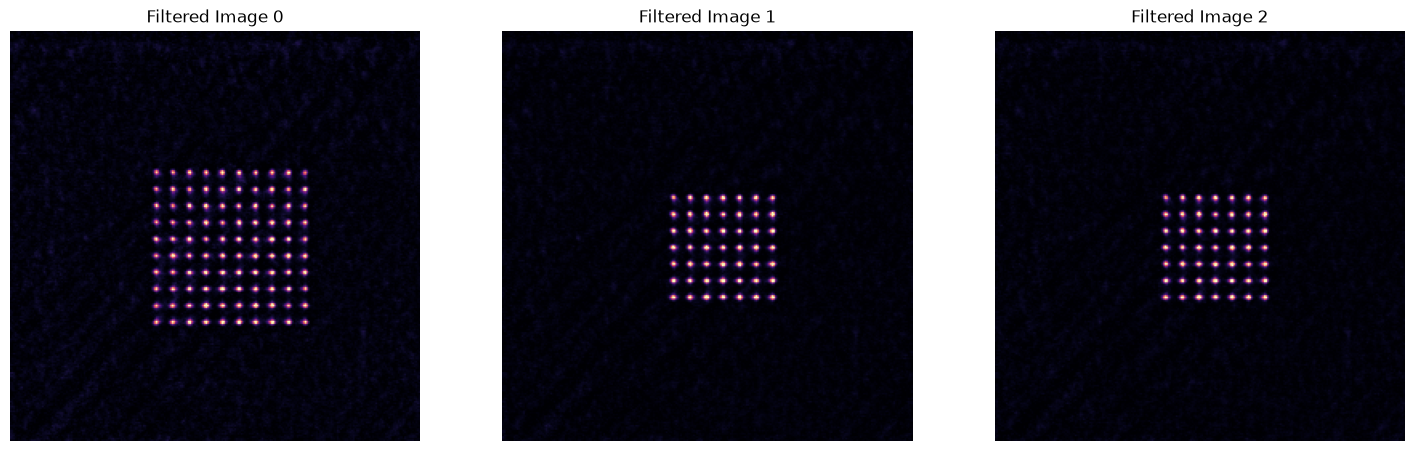

In [23]:
num_imgs_per_it = 3
tot_imgs = np.array(imgs_software)

plt.figure(figsize=(6*num_imgs_per_it, 6))
for n in range(num_imgs_per_it):
    imgs_n = tot_imgs[:, n, :, :]
    imgs__n_mean = imgs_n.mean(axis=0)
    imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)

    plt.subplot(1, num_imgs_per_it, n + 1)
    plt.imshow(imgs_n_mean_filtered, cmap='magma', vmax=0.6*imgs_n_mean_filtered.max())
    plt.title(f'Filtered Image {n}')
    plt.axis('off')
    
plt.show()

Looking for trap sites...
10x10 array detected.


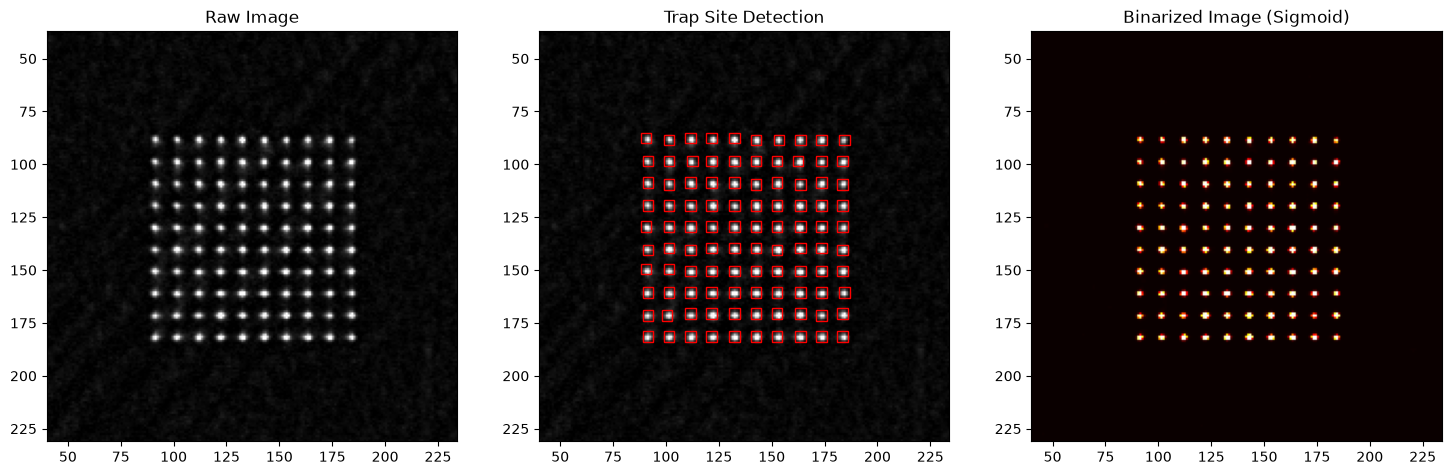

Trap (0, 0) Loading Probability : 54.55 %
Trap (0, 1) Loading Probability : 50.51 %
Trap (0, 2) Loading Probability : 62.63 %
Trap (0, 3) Loading Probability : 60.61 %
Trap (0, 4) Loading Probability : 58.59 %
Trap (0, 5) Loading Probability : 55.56 %
Trap (0, 6) Loading Probability : 56.57 %
Trap (0, 7) Loading Probability : 52.53 %
Trap (0, 8) Loading Probability : 63.64 %
Trap (0, 9) Loading Probability : 46.46 %
Trap (1, 0) Loading Probability : 55.56 %
Trap (1, 1) Loading Probability : 60.61 %
Trap (1, 2) Loading Probability : 54.55 %
Trap (1, 3) Loading Probability : 56.57 %
Trap (1, 4) Loading Probability : 57.58 %
Trap (1, 5) Loading Probability : 55.56 %
Trap (1, 6) Loading Probability : 61.62 %
Trap (1, 7) Loading Probability : 67.68 %
Trap (1, 8) Loading Probability : 50.51 %
Trap (1, 9) Loading Probability : 59.60 %
Trap (2, 0) Loading Probability : 54.55 %
Trap (2, 1) Loading Probability : 47.47 %
Trap (2, 2) Loading Probability : 57.58 %
Trap (2, 3) Loading Probability : 

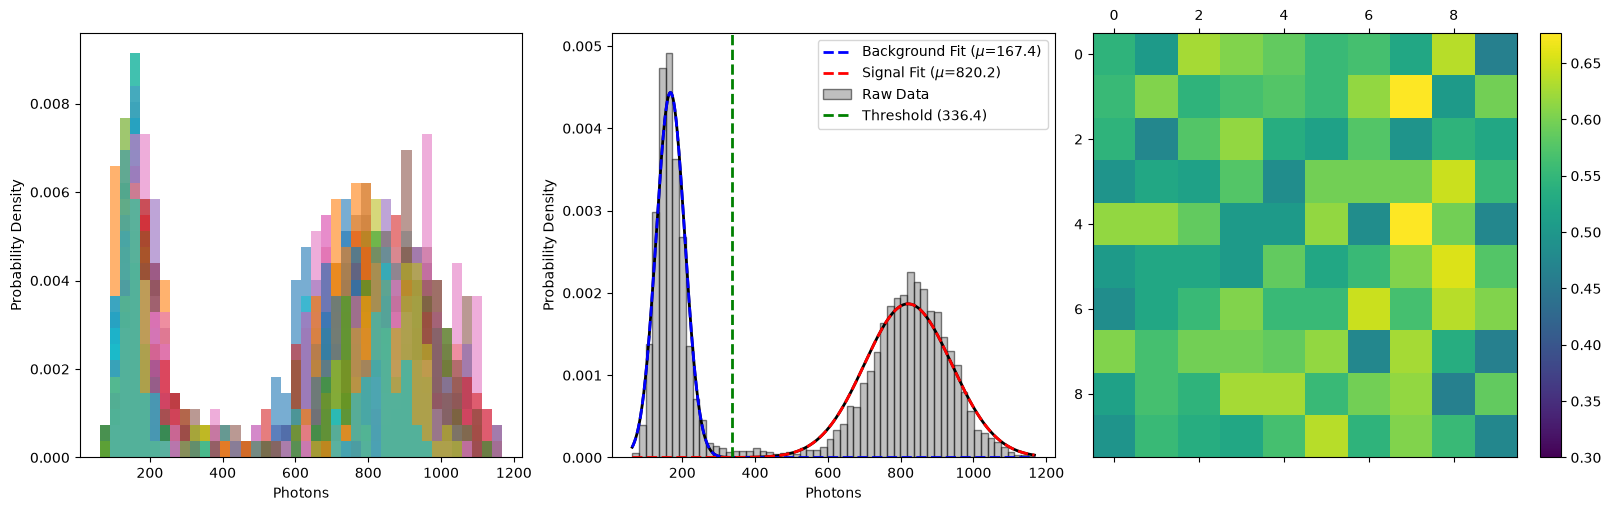

In [24]:
n = 0
imgs_n = tot_imgs[:, n, :, :]
imgs__n_mean = imgs_n.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)
array_shape_n = [10, 10]

window, feature_size = 5, 10
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, array_shape_n, detection_step=100)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_n]
photon_rates, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_n, threshold_detection=True, threshold=35, window_size=window, binning=60)

Looking for trap sites...
7x7 array detected.


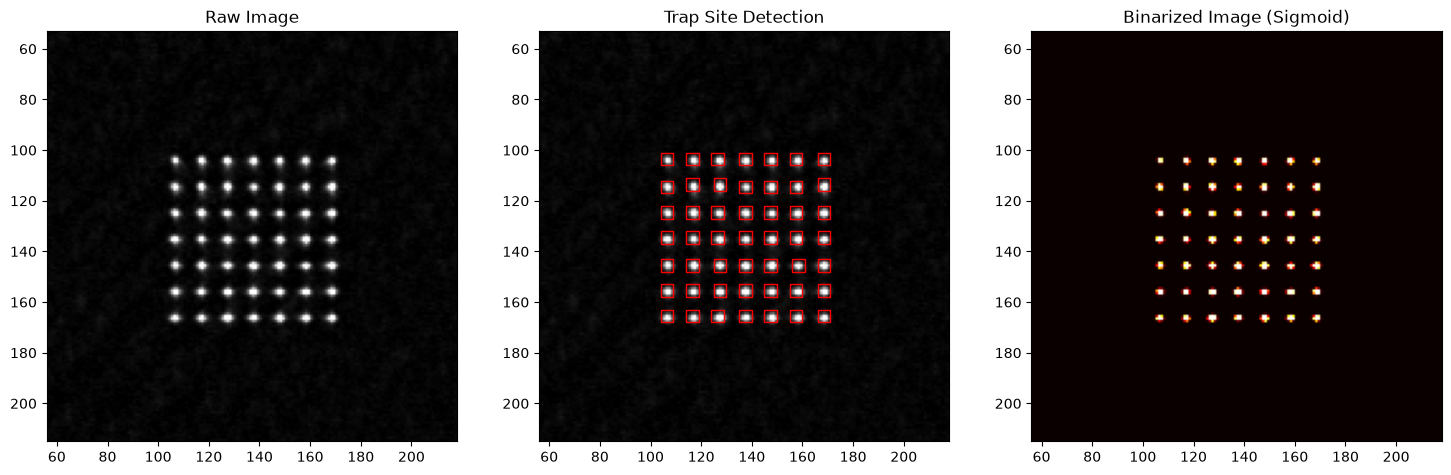

Trap (0, 0) Loading Probability : 83.84 %
Trap (0, 1) Loading Probability : 80.81 %
Trap (0, 2) Loading Probability : 88.89 %
Trap (0, 3) Loading Probability : 86.87 %
Trap (0, 4) Loading Probability : 90.91 %
Trap (0, 5) Loading Probability : 89.90 %
Trap (0, 6) Loading Probability : 85.86 %
Trap (1, 0) Loading Probability : 83.84 %
Trap (1, 1) Loading Probability : 86.87 %
Trap (1, 2) Loading Probability : 88.89 %
Trap (1, 3) Loading Probability : 85.86 %
Trap (1, 4) Loading Probability : 89.90 %
Trap (1, 5) Loading Probability : 86.87 %
Trap (1, 6) Loading Probability : 92.93 %
Trap (2, 0) Loading Probability : 85.86 %
Trap (2, 1) Loading Probability : 88.89 %
Trap (2, 2) Loading Probability : 88.89 %
Trap (2, 3) Loading Probability : 86.87 %
Trap (2, 4) Loading Probability : 84.85 %
Trap (2, 5) Loading Probability : 90.91 %
Trap (2, 6) Loading Probability : 90.91 %
Trap (3, 0) Loading Probability : 81.82 %
Trap (3, 1) Loading Probability : 88.89 %
Trap (3, 2) Loading Probability : 

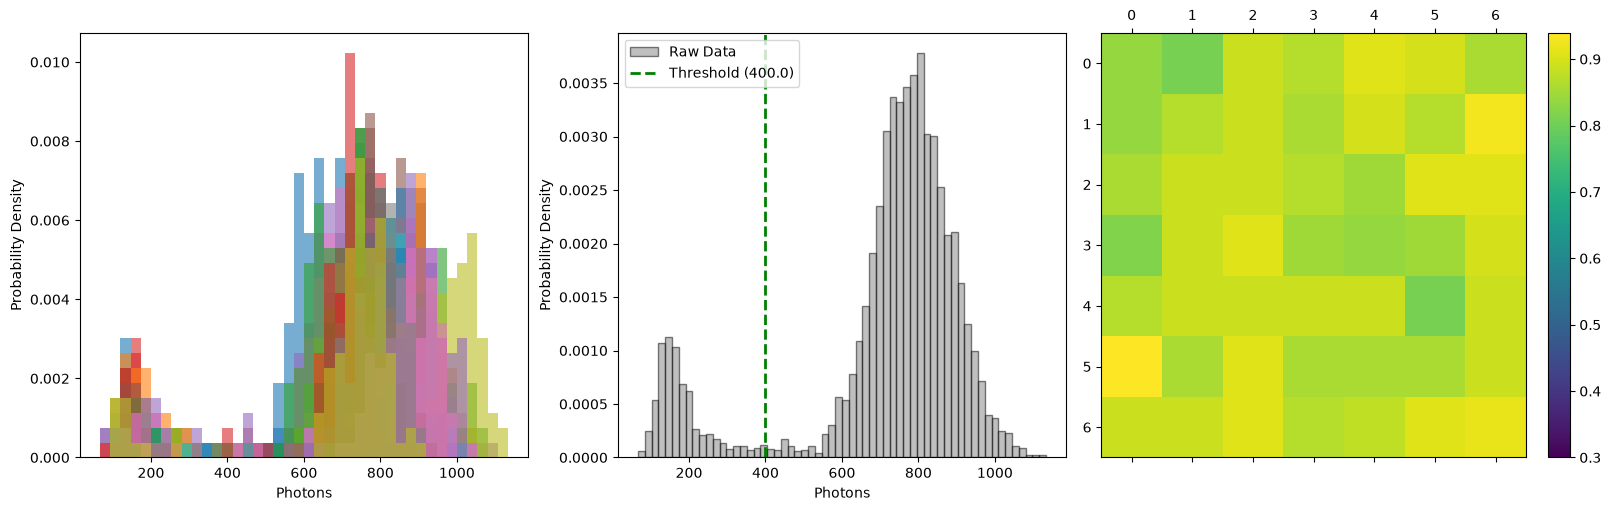

In [25]:
n = 1
imgs_n = tot_imgs[:, n, :, :]
imgs__n_mean = imgs_n.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)
array_shape_n = [7, 7]

window, feature_size = 5, 10
grid_positions_2, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, array_shape_n, detection_step=100)
an.visualize_results(imgs_n_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_n]
photon_rates, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_n, threshold_detection=False, threshold=400, window_size=window, binning=60)

### Final Array Trap Frequency Measurement

In [27]:
coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=an.convert_photons_to_counts(threshold_1)*1.1,
    grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
    detector=scorer, num_images=2
)

Occupancy via PSF detector (window 9, threshold 135.4).
Rearrangement node initialised.


In [28]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [31]:
modvcflist = np.linspace(-10.0, 10.0, 300)

N_iterations = 10 
tot_imgs_list = []
for it, modvcf in enumerate(modvcflist):
    imgs_list = []
    counter = 0
    while counter < N_iterations:
        print(f"Datapoint {it+1}: Running experiment iteration {counter+1} / {N_iterations}")
        rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))
        exp.start_motmaster_experiment({
                    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                    "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
                    "BackgroundDrop": 0, "TweezerModulation": 1, "tTweezerSetVVA0": 8.0, "tTweezerSetVVA1": 10.0, "tTweezerModulationVCF": modvcf, "tDelay3": 2000, "tTweezerModulationDuration": 2000})
        img0, imgs1, timings = await rearrangement_task
        print("Images acquired from rearrangement node.")
        if imgs1.sum() == 0:
            print(f"Empty image received at iteration {counter+1}. Repeating...")
        else:
            imgs_list.append([img0, *imgs1])
            counter += 1

    tot_imgs_list.append(imgs_list)
tot_imgs_array = np.array(tot_imgs_list)

Datapoint 1: Running experiment iteration 1 / 10
Rearrangement complete: 16 frames, 15.2690ms total (occupancy 0.1243ms, calculation+upload 15.1447ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 2 / 10
Rearrangement complete: 22 frames, 18.9768ms total (occupancy 0.1931ms, calculation+upload 18.7837ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 3 / 10


Rearrangement complete: 16 frames, 14.9422ms total (occupancy 0.1227ms, calculation+upload 14.8195ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 4 / 10
Rearrangement complete: 16 frames, 15.1611ms total (occupancy 0.1162ms, calculation+upload 15.0449ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 5 / 10
Rearrangement complete: 16 frames, 14.7047ms total (occupancy 0.1178ms, calculation+upload 14.5869ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 6 / 10
Rearrangement complete: 16 frames, 14.7196ms total (occupancy 0.1180ms, calculation+upload 14.6016ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 7 / 10
Rearrangement complete: 22 frames, 18.7770ms total (occupancy 0.1179ms, calculation+upload 18.6591ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 8 / 10
Rearrangement complete: 22 frames, 

In [33]:
survival_prob_list = []
for it, modvcf in enumerate(modvcflist):
    imgs1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in tot_imgs_array[it, :, 1, :, :]]
    imgs2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in tot_imgs_array[it, :, 2, :, :]]
    survival_prob = an.extract_survival_probability(imgs1, imgs2, grid_positions_2, [7,7], threshold=400, window_size=5)
    survival_prob_list.append(survival_prob)
    print(f"Modulation VCF: {modvcf:.2f}, Survival Probability: {survival_prob:.4f}")

modflist = np.linspace(10, 300, len(modvcflist))
surv_array = np.array(survival_prob_list)

def single_dip_gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + offset

def multi_dip_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, A4, mu4, sigma4, offset):
    return (single_dip_gaussian(x, A1, mu1, sigma1, 0) +
            single_dip_gaussian(x, A2, mu2, sigma2, 0) +
            single_dip_gaussian(x, A3, mu3, sigma3, 0) +
            single_dip_gaussian(x, A4, mu4, sigma4, 0) +  offset)

Modulation VCF: -10.00, Survival Probability: 0.9521
Modulation VCF: -9.93, Survival Probability: 0.9519
Modulation VCF: -9.87, Survival Probability: 0.9539
Modulation VCF: -9.80, Survival Probability: 0.9326
Modulation VCF: -9.73, Survival Probability: 0.9407
Modulation VCF: -9.67, Survival Probability: 0.9409
Modulation VCF: -9.60, Survival Probability: 0.9666
Modulation VCF: -9.53, Survival Probability: 0.9537
Modulation VCF: -9.46, Survival Probability: 0.9529
Modulation VCF: -9.40, Survival Probability: 0.9536
Modulation VCF: -9.33, Survival Probability: 0.9748
Modulation VCF: -9.26, Survival Probability: 0.9362
Modulation VCF: -9.20, Survival Probability: 0.9611
Modulation VCF: -9.13, Survival Probability: 0.9443
Modulation VCF: -9.06, Survival Probability: 0.9393
Modulation VCF: -9.00, Survival Probability: 0.9319
Modulation VCF: -8.93, Survival Probability: 0.9414
Modulation VCF: -8.86, Survival Probability: 0.9463
Modulation VCF: -8.80, Survival Probability: 0.9444
Modulation 

Resonances = 34.81, 64.84, 101.16, 202.57 kHz
Trap Frequencies = 17.40, 32.42, 50.58, 101.29 kHz


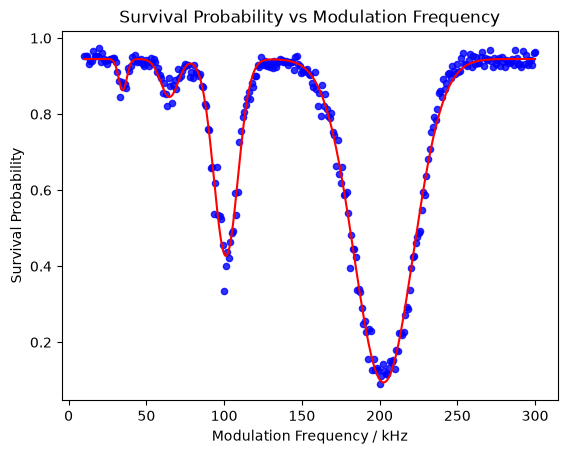

In [39]:
guess = [-0.1, 33, 1, 
         -0.2, 66, 11, 
         -0.6, 100, 10,
         -0.8, 200, 10, 
          0.9]

popt, pcov = curve_fit(multi_dip_gaussian, modflist, surv_array, p0=guess)
popt[3] = -0.1
xfit = np.linspace(modflist.min(), modflist.max(), 1000)
yfit = multi_dip_gaussian(xfit, *popt)

plt.scatter(modflist, surv_array, color="blue", alpha=0.8, s=20)
plt.plot(xfit, yfit, color='red')
plt.xlabel("Modulation Frequency / kHz")
plt.ylabel("Survival Probability")
plt.title("Survival Probability vs Modulation Frequency")

print(f"Resonances = {popt[1]:.2f}, {popt[4]:.2f}, {popt[7]:.2f}, {popt[10]:.2f} kHz")
print(f"Trap Frequencies = {popt[1]/2:.2f}, {popt[4]/2:.2f}, {popt[7]/2:.2f}, {popt[10]/2:.2f} kHz")

#### Save Data

In [40]:
import os
import pickle
import time

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\20Aug26"
dataset_title = "final_7x7_array_trap_frequency_measurement"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save surv_array and modflist to a pickle file
data_to_save = {
    "surv_array": surv_array,
    "modflist": modflist
}

with open(os.path.join(data_dir, dataset_title, "trap_frequency_data.pkl"), "wb") as f:
    pickle.dump(data_to_save, f)

# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    Trap frequency measurement of the final 7x7 array after rearrangement, scanning a modulation frequency range from 10 kHz to 300 kHz. Modulation duration used is 20ms. 
    """)

### Final Array Temperature Measurement

In [41]:
coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=an.convert_photons_to_counts(threshold_1)*1.1,
    grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
    detector=scorer, num_images=2
)

Occupancy via PSF detector (window 9, threshold 135.4).
Rearrangement node initialised.


In [42]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [ ]:
N_datapoints = 20
N_iterations = 50 
drop_duration_list = np.linspace(1, N_datapoints, N_datapoints).astype('int')

tot_imgs_list = []
for it, dropt in enumerate(drop_duration_list):
    imgs_list = []

    counter = 0
    while counter < N_iterations:
        print(f"Datapoint {it+1}: Running experiment iteration {counter+1} / {N_iterations}")
        rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))
        exp.start_motmaster_experiment({
                    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                    "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
                    "BackgroundDrop": 1, "tDropDuration": int(dropt), "tTweezerSetVVA0": 8.0, "tTweezerSetVVA1": 10.0, "tDelay3":800})
        img0, imgs1, timings = await rearrangement_task
        print("Images acquired from rearrangement node.")
        if imgs1.sum() == 0:
            print(f"Empty image received at iteration {counter+1}. Repeating...")
        else:
            imgs_list.append([img0, *imgs1])
            counter += 1

    tot_imgs_list.append(imgs_list)
tot_imgs_array = np.array(tot_imgs_list)

Datapoint 1: Running experiment iteration 1 / 50


Drop time: 10.00 us, Survival Probability: 0.8676
Drop time: 20.00 us, Survival Probability: 0.5635
Drop time: 30.00 us, Survival Probability: 0.4096
Drop time: 40.00 us, Survival Probability: 0.2815


Drop time: 50.00 us, Survival Probability: 0.2259
Drop time: 60.00 us, Survival Probability: 0.2132
Drop time: 70.00 us, Survival Probability: 0.1896
Drop time: 80.00 us, Survival Probability: 0.1832
Drop time: 90.00 us, Survival Probability: 0.1763
Drop time: 100.00 us, Survival Probability: 0.1644
Drop time: 110.00 us, Survival Probability: 0.1661
Drop time: 120.00 us, Survival Probability: 0.1619
Drop time: 130.00 us, Survival Probability: 0.1603
Drop time: 140.00 us, Survival Probability: 0.1606
Drop time: 150.00 us, Survival Probability: 0.1459
Drop time: 160.00 us, Survival Probability: 0.1346
Drop time: 170.00 us, Survival Probability: 0.1538
Drop time: 180.00 us, Survival Probability: 0.1441
Drop time: 190.00 us, Survival Probability: 0.1504
Drop time: 200.00 us, Survival Probability: 0.1346


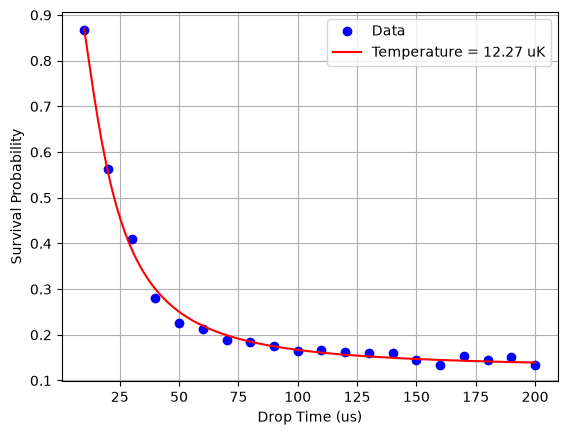

Extracted Temperature = 12.27 uK


In [45]:
from scipy import integrate

survival_prob_list = []
for it, dropt in enumerate(drop_duration_list):
    imgs1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in tot_imgs_array[it, :, 1, :, :]]
    imgs2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in tot_imgs_array[it, :, 2, :, :]]
    survival_prob = an.extract_survival_probability(imgs1, imgs2, grid_positions_2, [7,7], threshold=400, window_size=5)
    survival_prob_list.append(survival_prob)
    print(f"Drop time: {dropt*10:.2f} us, Survival Probability: {survival_prob:.4f}")
surv_array = np.array(survival_prob_list)


kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

wr = 2 * np.pi * 101.285e3
w0 = 0.587e-6
U0 = 1/4 * wr**2 * mRb * w0**2

def recapture_prob_fit(tarray, T, a, b):
    probs = []
    for t in tarray:
        escape_v_ineq = lambda ve, t: 0.5 * mRb * ve**2 - U0 * np.exp(- 2 * ve**2 * t**2 / w0**2)
        maxwell_p = lambda v, T: (mRb*v)/(kB*T) * np.exp(-mRb*v**2 / (2*kB*T))
        xx = np.linspace(0, 1, 100000)
        y = escape_v_ineq(xx, t)
        ve = xx[np.argmin(np.abs(y))]
        prob = integrate.quad(maxwell_p, 0, ve, args=(T))[0]
        probs.append(prob)
    return a * np.array(probs) + b

def extract_temperature(dropTimeList, survival_prob_list, plot=True):
    dropt = dropTimeList*10*1e-6
    survival_prob_list = np.array(survival_prob_list)
    survival_prob_list = survival_prob_list[~np.isnan(survival_prob_list)]
    dropt = dropt[~np.isnan(survival_prob_list)]
    try:
        params, pcov = curve_fit(recapture_prob_fit, dropt, survival_prob_list, p0 = [10e-6, 1.5, 0.1])
        temperature = params[0] * 1e6
    except:
        temperature = 100
    if plot:
        xfit = np.linspace(dropt.min(), dropt.max(), 100)
        yfit = recapture_prob_fit(xfit, temperature*1e-6, params[1], params[2])
        plt.figure()
        plt.plot(dropt*1e6, survival_prob_list, 'o', label='Data', color='blue')
        plt.plot(xfit*1e6, yfit, '-', color='red', label=f'Temperature = {temperature:.2f} uK')
        plt.grid()
        plt.xlabel('Drop Time (us)')
        plt.ylabel('Survival Probability')
        plt.legend()
        plt.show()

    return temperature

temperature = extract_temperature(drop_duration_list, surv_array)
print(f"Extracted Temperature = {temperature:.2f} uK")

#### Save Data

In [46]:
import os
import pickle
import time

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\20Aug26"
dataset_title = "final_7x7_array_temperature_measurement"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save surv_array and modflist to a pickle file
data_to_save = {
    "surv_array": surv_array,
    "drop_durations": drop_duration_list
}

with open(os.path.join(data_dir, dataset_title, "temperature_data.pkl"), "wb") as f:
    pickle.dump(data_to_save, f)

# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    Temperature measurement of the final 7x7 array after rearrangement, scanning a drop duration range from 10 us to 200 us. The extracted temperature is {temperature:.2f} uK.
    The trap frequency measurement was used to calibrate the trap depth for the temperature extraction. The recapture probability was fitted to a Maxwell-Boltzmann distribution to extract the temperature.
    """)

### Initial Array Temp Measurement - Double Check

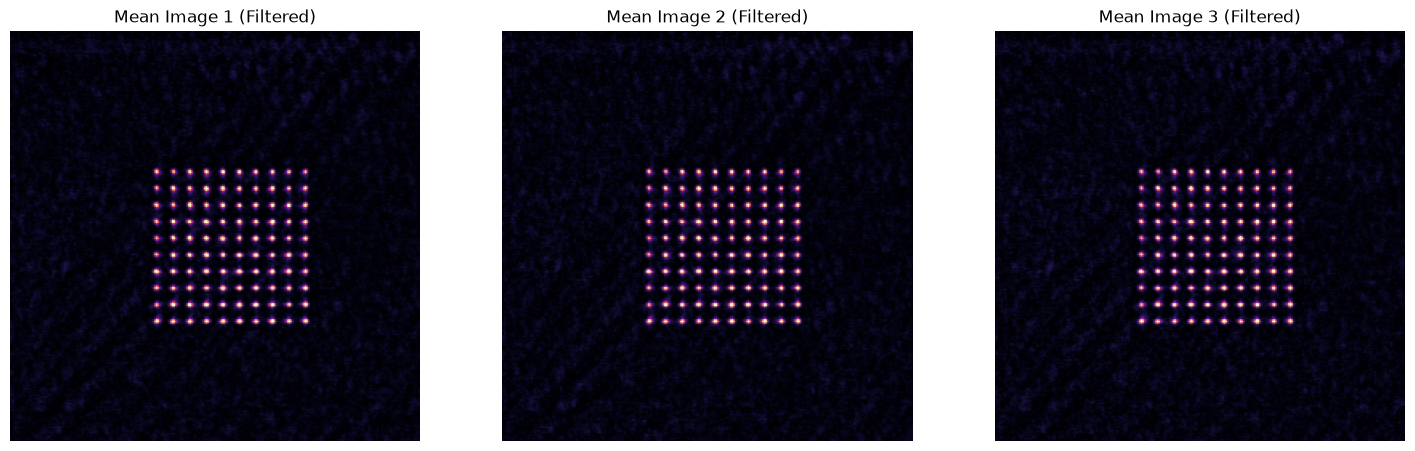

In [443]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 3)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 3)
imgs1, imgs2, imgs3 = imgs[::3], imgs[1::3], imgs[2::3]

imgs1_mean = np.mean(imgs1, axis=0)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)
imgs2_mean = np.mean(imgs2, axis=0)
imgs2_mean_filtered = an.morphological_tophat_high_pass(imgs2_mean, feature_size=feature_size)
imgs3_mean = np.mean(imgs3, axis=0)
imgs3_mean_filtered = an.morphological_tophat_high_pass(imgs3_mean, feature_size=feature_size)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Mean Image 1 (Filtered)')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(imgs2_mean_filtered, cmap='magma', vmax=0.6*imgs2_mean_filtered.max())
plt.title('Mean Image 2 (Filtered)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgs3_mean_filtered, cmap='magma', vmax=0.6*imgs3_mean_filtered.max())
plt.title('Mean Image 3 (Filtered)')
plt.axis('off')
plt.show()

In [12]:
# Experiment and camera setup
N_datapoints = 20
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 3)

drop_duration_list = np.linspace(1, N_datapoints, N_datapoints).astype('int')
surv_array = np.zeros(N_datapoints)

for i, drop_t in enumerate(drop_duration_list):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
        "BackgroundDrop": 1, "tDropDuration": int(drop_t), "tDelay3": 800})

    imgs = hamcam.acquire_n_frames(n_iterations * 3)
    imgs1, imgs2, imgs3 = imgs[::3], imgs[1::3], imgs[2::3]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    imgs_filtered_3 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs3]
    survival_probability = an.extract_survival_probability(imgs_filtered_2, imgs_filtered_3, grid_positions_1, array_shape_1, window_size=window)
    surv_array[i] = survival_probability
    print(f"Drop time = {int(drop_t)*10} us  |  Survival probability: {survival_probability*100:.4f} %")

Drop time = 10 us  |  Survival probability: 92.3662 %
Drop time = 20 us  |  Survival probability: 63.4467 %
Drop time = 30 us  |  Survival probability: 43.8471 %
Drop time = 40 us  |  Survival probability: 35.7553 %
Drop time = 50 us  |  Survival probability: 27.0589 %
Drop time = 60 us  |  Survival probability: 23.3247 %
Drop time = 70 us  |  Survival probability: 21.4834 %
Drop time = 80 us  |  Survival probability: 19.9187 %
Drop time = 90 us  |  Survival probability: 19.5370 %
Drop time = 100 us  |  Survival probability: 19.2939 %
Drop time = 110 us  |  Survival probability: 17.2698 %
Drop time = 120 us  |  Survival probability: 19.4185 %
Drop time = 130 us  |  Survival probability: 17.3939 %
Drop time = 140 us  |  Survival probability: 16.8547 %
Drop time = 150 us  |  Survival probability: 16.8343 %
Drop time = 160 us  |  Survival probability: 17.1153 %
Drop time = 170 us  |  Survival probability: 17.4070 %
Drop time = 180 us  |  Survival probability: 15.8041 %
Drop time = 190 us 

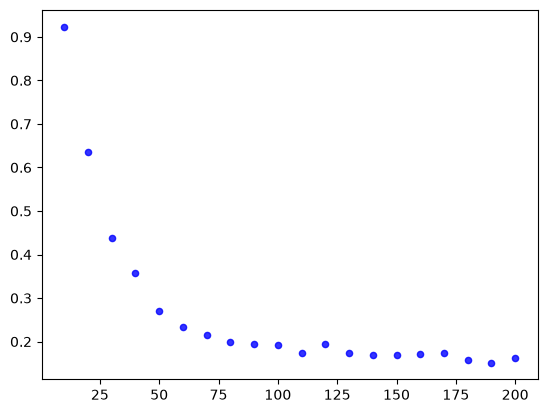

In [21]:
plt.scatter(drop_duration_list*10, surv_array, color="blue", alpha=0.8, s=20)

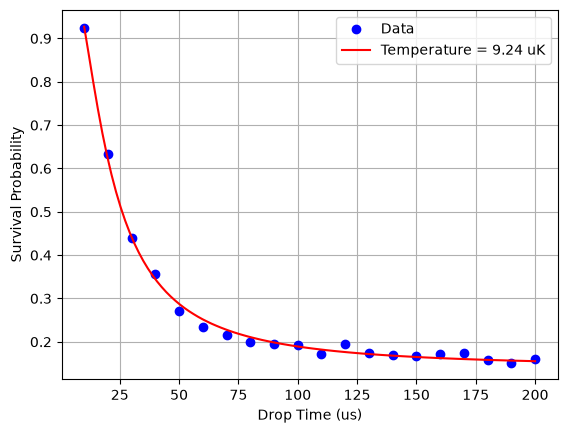

Extracted Temperature = 9.24 uK


In [34]:
from scipy import integrate

kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

wr = 2 * np.pi * 68e3
w0 = 0.587e-6
U0 = 1/4 * wr**2 * mRb * w0**2

def recapture_prob_fit(tarray, T, a, b):
    probs = []
    for t in tarray:
        escape_v_ineq = lambda ve, t: 0.5 * mRb * ve**2 - U0 * np.exp(- 2 * ve**2 * t**2 / w0**2)
        maxwell_p = lambda v, T: (mRb*v)/(kB*T) * np.exp(-mRb*v**2 / (2*kB*T))
        xx = np.linspace(0, 1, 100000)
        y = escape_v_ineq(xx, t)
        ve = xx[np.argmin(np.abs(y))]
        prob = integrate.quad(maxwell_p, 0, ve, args=(T))[0]
        probs.append(prob)
    return a * np.array(probs) + b

def extract_temperature(dropTimeList, survival_prob_list, plot=True):
    dropt = dropTimeList*10*1e-6
    survival_prob_list = np.array(survival_prob_list)
    survival_prob_list = survival_prob_list[~np.isnan(survival_prob_list)]
    dropt = dropt[~np.isnan(survival_prob_list)]
    try:
        params, pcov = curve_fit(recapture_prob_fit, dropt, survival_prob_list, p0 = [10e-6, 1.5, 0.1])
        temperature = params[0] * 1e6
    except Exception as e:
        print(f"Curve fitting failed: {e}")
        temperature = 100
    if plot:
        xfit = np.linspace(dropt.min(), dropt.max(), 100)
        yfit = recapture_prob_fit(xfit, temperature*1e-6, params[1], params[2])
        plt.figure()
        plt.plot(dropt*1e6, survival_prob_list, 'o', label='Data', color='blue')
        plt.plot(xfit*1e6, yfit, '-', color='red', label=f'Temperature = {temperature:.2f} uK')
        plt.grid()
        plt.xlabel('Drop Time (us)')
        plt.ylabel('Survival Probability')
        plt.legend()
        plt.show()

    return temperature

temperature = extract_temperature(drop_duration_list, surv_array)
print(f"Extracted Temperature = {temperature:.2f} uK")

#### Save Data

In [35]:
import os
import pickle
import time

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\20Aug26"
dataset_title = "initial_10x10_array_temperature_measurement"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save surv_array and modflist to a pickle file
data_to_save = {
    "surv_array": surv_array,
    "drop_durations": drop_duration_list
}

with open(os.path.join(data_dir, dataset_title, "temperature_data.pkl"), "wb") as f:
    pickle.dump(data_to_save, f)

# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    Temperature measurement of the initial 10x10 array after rearrangement, scanning a drop duration range from 10 us to 200 us. The extracted temperature is {temperature:.2f} uK.
    The trap frequency measurement was used to calibrate the trap depth for the temperature extraction. The recapture probability was fitted to a Maxwell-Boltzmann distribution to extract the temperature.
    """)

---

In [36]:
hamcam.close()
motcam.close()
slm.close()

ImagEM X2 camera closed.
Thorlabs TLCamera - motcam - closed.
SLM 1 closed.
